In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.signal import find_peaks

from matplotlib import rcParams
rcParams['font.family'] = 'Times New Roman'
rcParams['mathtext.fontset'] = 'stix'
rcParams['axes.unicode_minus'] = False
rcParams.update({
    'font.size': 14,         # base font size
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,   # legend a bit smaller
    'figure.titlesize': 14,
    'legend.frameon': False,
})

# Data readout

In [4]:
base_folder = "./data/"

# Get all numeric subfolders

subfolders = sorted([f for f in os.listdir(base_folder) if f.isdigit()], key=lambda x: int(x))


specs = []
for sub in subfolders:
    print(sub)
    folder_path = os.path.join(base_folder, sub)
    files = glob.glob(folder_path + "/*.dat")

    sub_data = []
    for f in files:
        df = pd.read_csv(f, sep=r"\s+", header=None)
        df.columns = ['x', 'y']
        sub_data.append(df["y"].values)
    sub_data = np.mean(sub_data, axis = 0)

    specs.append(sub_data)

x_array = df["x"].values

0
200
400
600
800
1000
1200
1400
1600
1800
2000


250002


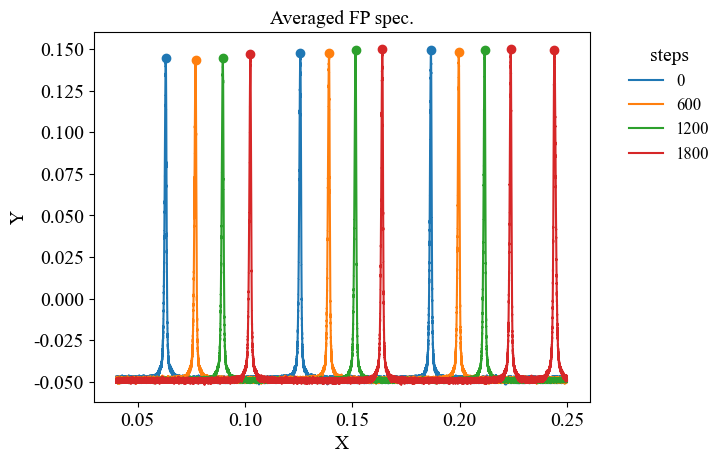

In [28]:
# filter out the useless peaks
slice = 20000
print(len(specs[0]))
peaks_list = []
for id, sub in enumerate(subfolders):
    if id%3==0:
        plt.plot(x_array[slice:len(specs[0])//2], specs[id][slice:len(specs[0])//2], label = sub)
        peaks, props = find_peaks(specs[id][slice:len(specs[0])//2], height=0.1, distance=2000)
        plt.scatter(x_array[slice:len(specs[0])//2][peaks],specs[id][slice:len(specs[0])//2][peaks])
        peaks_list.append(peaks)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Averaged FP spec.")
plt.legend(title="steps",bbox_to_anchor=(1.05, 1), loc="upper left")
# plt.grid(True)
plt.show()

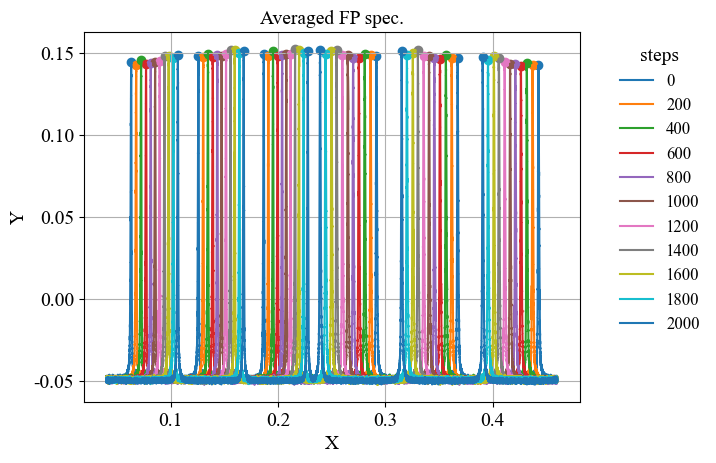

In [32]:
# filter out the useless peaks
slice = 20000

peaks_list = []
for id, sub in enumerate(subfolders):
    plt.plot(x_array[slice:-slice], specs[id][slice:-slice], label = sub)
    peaks, props = find_peaks(specs[id][slice:-slice], height=0.1, distance=2000)
    plt.scatter(x_array[slice:-slice][peaks],specs[id][slice:-slice][peaks])
    peaks_list.append(peaks)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Averaged FP spec.")
plt.legend(title="steps",bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

In [34]:
# the positions of each peak
peaks_positions = x_array[peaks_list]
print(peaks_positions)

# the positions difference w.r.t. the original position
positions_moves = peaks_positions - peaks_positions[0]
print(positions_moves)

# the spacing between neighbers for each step
peak_spacing = np.diff(peaks_positions,axis = 1)
print(peak_spacing)

[[0.02311  0.085792 0.14663  0.251576 0.327188 0.402536]
 [0.027834 0.090286 0.150988 0.246122 0.321688 0.397004]
 [0.03238  0.09465  0.155272 0.240664 0.316278 0.391666]
 [0.037026 0.09916  0.159626 0.235162 0.31078  0.386168]
 [0.041354 0.103398 0.16379  0.229896 0.305524 0.380982]
 [0.045462 0.107382 0.167674 0.224894 0.300552 0.37608 ]
 [0.049704 0.111518 0.171644 0.21985  0.295518 0.37104 ]
 [0.054192 0.11575  0.175846 0.214484 0.290184 0.365666]
 [0.058042 0.119544 0.179516 0.209688 0.285496 0.360998]
 [0.062562 0.123982 0.18378  0.204176 0.279936 0.355526]
 [0.066632 0.127934 0.187652 0.199124 0.275036 0.350552]]
[[ 0.        0.        0.        0.        0.        0.      ]
 [ 0.004724  0.004494  0.004358 -0.005454 -0.0055   -0.005532]
 [ 0.00927   0.008858  0.008642 -0.010912 -0.01091  -0.01087 ]
 [ 0.013916  0.013368  0.012996 -0.016414 -0.016408 -0.016368]
 [ 0.018244  0.017606  0.01716  -0.02168  -0.021664 -0.021554]
 [ 0.022352  0.02159   0.021044 -0.026682 -0.026636 -0.02

# linear fit

In [37]:
# at one side, there are only 3 sets of peaks, the spacing between the center 2 sets are meaningless
# only the first two and last two can be use
effective_spacings = peak_spacing[0][[0,1,-2,-1]]
print(effective_spacings)

effective_moves = positions_moves[:,[0,1,-2,-1]]
print(effective_moves)

FSR = 375e3 #kHz

# handle it linearly and get the frequency change
freq_changes = effective_moves/effective_spacings * FSR
print(freq_changes)

[0.062682 0.060838 0.075612 0.075348]
[[ 0.        0.        0.        0.      ]
 [ 0.004724  0.004494 -0.0055   -0.005532]
 [ 0.00927   0.008858 -0.01091  -0.01087 ]
 [ 0.013916  0.013368 -0.016408 -0.016368]
 [ 0.018244  0.017606 -0.021664 -0.021554]
 [ 0.022352  0.02159  -0.026636 -0.026456]
 [ 0.026594  0.025726 -0.03167  -0.031496]
 [ 0.031082  0.029958 -0.037004 -0.03687 ]
 [ 0.034932  0.033752 -0.041692 -0.041538]
 [ 0.039452  0.03819  -0.047252 -0.04701 ]
 [ 0.043522  0.042142 -0.052152 -0.051984]]
[[      0.               0.               0.               0.        ]
 [  28261.70196908   27700.61483843  -27277.41635528  -27532.25043142]
 [  55458.5049224    54599.92128144  -54108.47498838  -54098.98087301]
 [  83253.56574974   82399.15807521  -81375.97228317  -81462.01646085]
 [ 109146.16653768  108521.81176574 -107443.26325833 -107272.25701352]
 [ 133722.60000275  133078.83212985 -132102.0476435  -131669.0554339 ]
 [ 159100.69901902  158572.76692552 -157068.322408   -156752.6

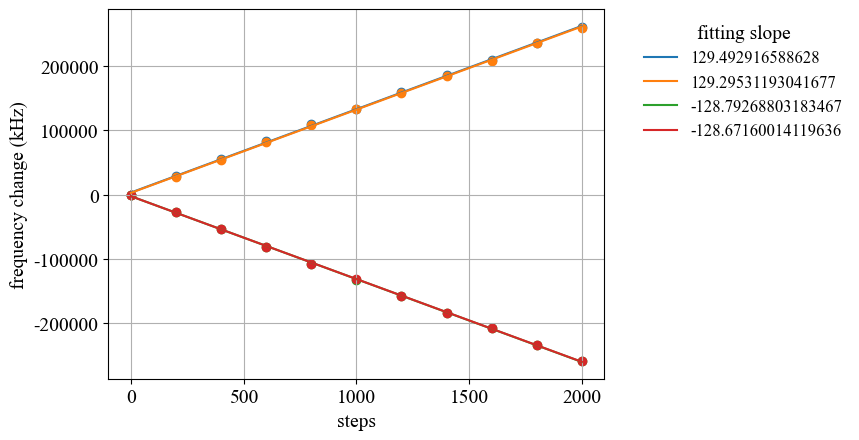

In [39]:
# linear fit the frequency and steps
a_fit_list = []
for i in range(len(freq_changes[0])):
    stepper_range = np.array(subfolders).astype(int)
    plt.scatter(stepper_range,freq_changes[:,i])
    a, b = np.polyfit(stepper_range, freq_changes[:,i], 1)
    plt.plot(stepper_range,a*stepper_range+b, label = f"{a}")
    a_fit_list.append(a)

plt.ylabel("frequency change (kHz)")
plt.xlabel("steps")
plt.legend(title="fitting slope",bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

In [41]:
print(f"the slope is {np.mean(np.abs(a_fit_list))} kHz/step (linear PZT response approx.)")

the slope is 129.06312917301895 kHz/step (linear PZT response approx.)


# quadratic fit

In [44]:
# use three peaks to fit quadratically
# the rising side and falling side will be average separately

# estimate F
a_rising, b_rising, c_rising = np.polyfit(peaks_positions[0][0:3], np.arange(3) * FSR, 2)
a_falling, b_falling, c_falling = np.polyfit(peaks_positions[0][3:], np.arange(3) * FSR, 2)

# calculate the frequency change
freq_changes_rising = a_rising * peaks_positions[:,0:3]**2 + b_rising * peaks_positions[:,0:3] + c_rising - np.arange(3) * FSR
freq_changes_falling = a_falling * peaks_positions[:,3:]**2 + b_falling * peaks_positions[:,3:] + c_falling - np.arange(3) * FSR

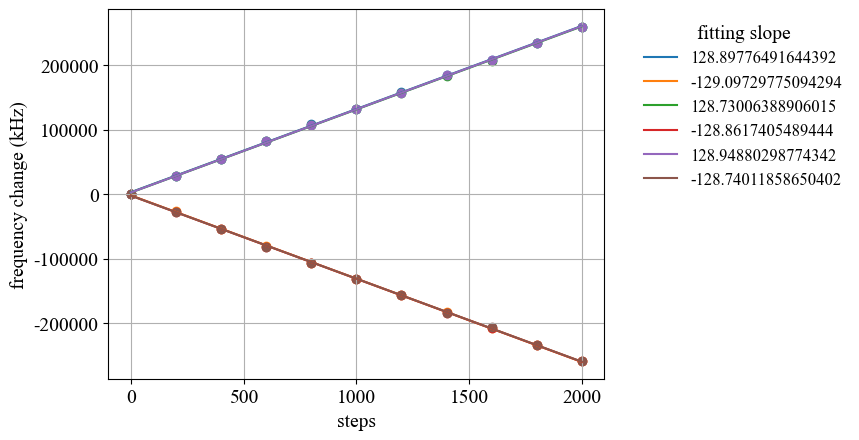

In [46]:
# linear fit the frequency and steps
a_fit_quadratic_list = []
for i in range(len(freq_changes_falling[0])):
    stepper_range = np.array(subfolders).astype(int)
    plt.scatter(stepper_range,freq_changes_rising[:,i])
    a_rising, b_rising = np.polyfit(stepper_range, freq_changes_rising[:,i], 1)
    plt.plot(stepper_range,a_rising*stepper_range+b_rising, label = f"{a_rising}")

    plt.scatter(stepper_range,freq_changes_falling[:,i])
    a_falling, b_falling = np.polyfit(stepper_range, freq_changes_falling[:,i], 1)
    plt.plot(stepper_range,a_falling*stepper_range+b_falling, label = f"{a_falling}")
    
    a_fit_quadratic_list.append(a_rising)
    a_fit_quadratic_list.append(a_falling)

plt.ylabel("frequency change (kHz)")
plt.xlabel("steps")
plt.legend(title="fitting slope",bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

In [156]:
print(f"the slope is {np.mean(np.abs(a_fit_quadratic_list))} kHz/step (quadratic PZT response approx.)")

the slope is 128.8792981132731 kHz/step (quadratic PZT response approx.)


# test code

Text(0, 0.5, 'intensity')

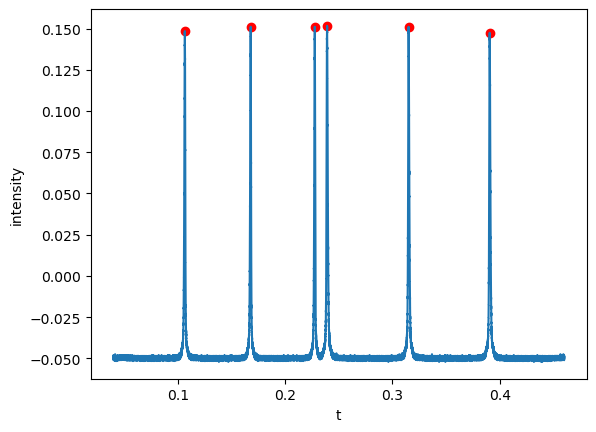

In [35]:
id = -1
slice = 20000
plt.plot(x_array[slice:-slice],specs[id][slice:-slice],label = subfolders[id])


peaks, props = find_peaks(specs[id][slice:-slice], height=0.1, distance=2000)

plt.scatter(x_array[slice:-slice][peaks],specs[id][slice:-slice][peaks],c="r")
plt.xlabel("t")
plt.ylabel("intensity")